In [ ]:
# Point 1: Load and preprocess the Pima Indians Diabetes Dataset

import pandas as pd
import numpy as np

# Load CSV
df = pd.read_csv('/content/diabetes.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

# Features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Replace impossible zero values with NaN
zero_columns = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

X[zero_columns] = X[zero_columns].replace(0, np.nan)

# Fill missing values using median
X[zero_columns] = X[zero_columns].fillna(X[zero_columns].median())

print("\nAfter preprocessing:")
display(X.head())

print("\nTarget distribution:")
print(y.value_counts())

Dataset Shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

After preprocessing:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72.0,35,169.5,33.6,0.627,50
1,1,85,66.0,29,102.5,26.6,0.351,31
2,8,183,64.0,32,169.5,23.3,0.672,32
3,1,89,66.0,23,94.0,28.1,0.167,21
4,0,137,40.0,35,168.0,43.1,2.288,33



Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
# Point 2: Train-test split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 614
Testing samples: 154


In [ ]:
# Point 3: Train Logistic Regression model

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [ ]:
# Point 4: K-Fold Cross-Validation

from sklearn.model_selection import StratifiedKFold, cross_val_score

# 5-fold stratified cross-validation
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracy = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring='accuracy'
)

print("Accuracy for each fold:")
print(cv_accuracy)

print("\nMean Cross-Validation Accuracy:",
      cv_accuracy.mean())

print("Standard Deviation:",
      cv_accuracy.std())

Accuracy for each fold:
[0.77235772 0.80487805 0.81300813 0.7804878  0.77868852]

Mean Cross-Validation Accuracy: 0.7898840463814475
Standard Deviation: 0.016002152408391687


In [ ]:
# Point 5: Accuracy and F1-score

from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

# Predictions on test data
y_pred = model.predict(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Test Accuracy:", accuracy)
print("Test F1-Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7077922077922078
Test F1-Score: 0.5714285714285714

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154


Confusion Matrix:
[[79 21]
 [24 30]]


Brier Score: 0.16920438714396296


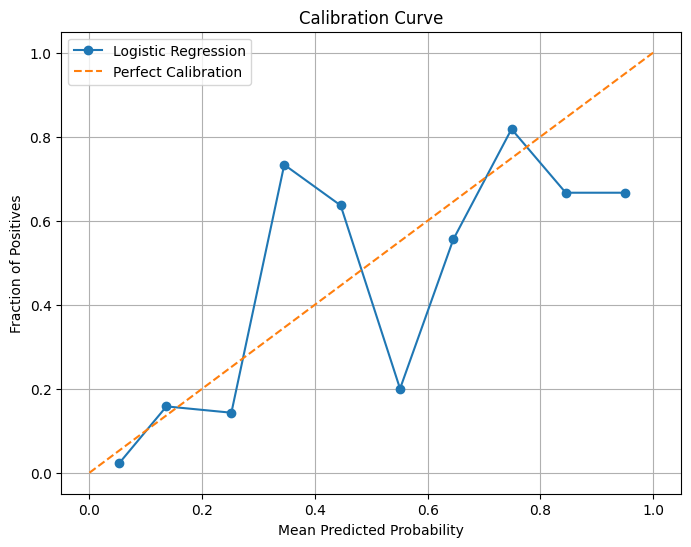

In [ ]:
# Point 6: Brier Score and Calibration Curve

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# Probability of class 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Brier Score
brier = brier_score_loss(y_test, y_prob)

print("Brier Score:", brier)

# Calibration curve
prob_true, prob_pred = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy='uniform'
)

# Plot calibration curve
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker='o',
    label='Logistic Regression'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect Calibration'
)

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Point 7: Install SHAP

!pip install -q shap

In [ ]:
# Point 7: SHAP explanation

import shap

# Create SHAP explainer
explainer = shap.LinearExplainer(
    model,
    X_train_scaled
)

# Calculate SHAP values
shap_values = explainer(X_test_scaled)

print("SHAP explanation generated successfully.")

SHAP explanation generated successfully.


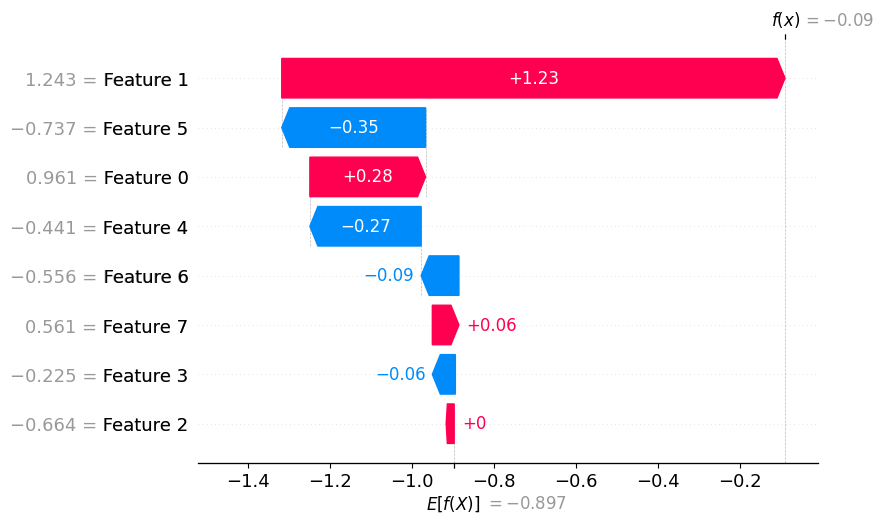

In [ ]:
# Explain the first test sample

sample_index = 0

shap.plots.waterfall(
    shap_values[sample_index],
    max_display=8
)

In [ ]:
# Point 8: SHAP feature importance

import numpy as np
import pandas as pd

# Mean absolute SHAP value for each feature
feature_importance = np.abs(
    shap_values.values
).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP Value': feature_importance
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Mean Absolute SHAP Value',
    ascending=False
)

print("Feature Importance:")
display(importance_df)

Feature Importance:


,Feature,Mean Absolute SHAP Value
1,Glucose,0.804222
4,Insulin,0.501050
5,BMI,0.384932
0,Pregnancies,0.304877
3,SkinThickness,0.208257
7,Age,0.136612
6,DiabetesPedigreeFunction,0.130258
2,BloodPressure,0.003048


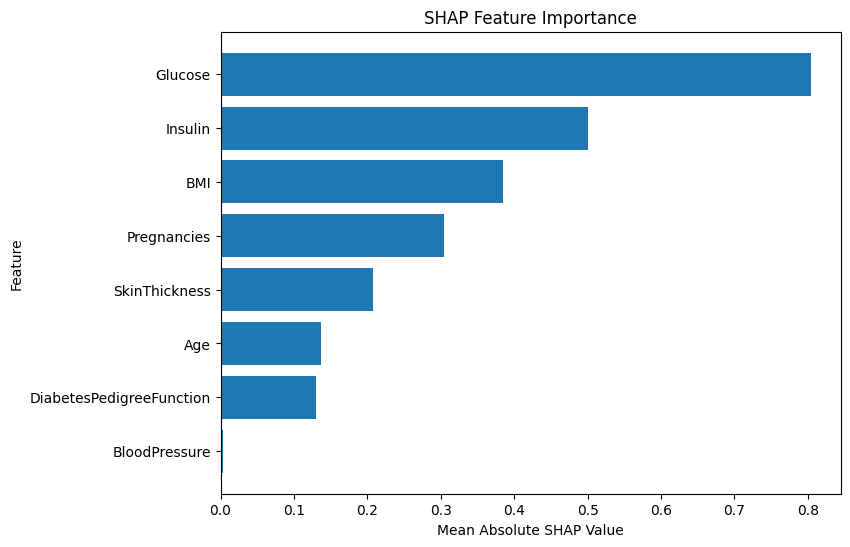

In [ ]:
# Feature importance plot

plt.figure(figsize=(8, 6))

plt.barh(
    importance_df['Feature'],
    importance_df['Mean Absolute SHAP Value']
)

plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.title('SHAP Feature Importance')

plt.gca().invert_yaxis()

plt.show()

In [ ]:
# Point 9: Summary of model evaluation

print("=" * 50)
print("MODEL EVALUATION SUMMARY")
print("=" * 50)

print(f"Dataset size       : {len(df)}")
print(f"Training samples   : {len(X_train)}")
print(f"Testing samples    : {len(X_test)}")

print("\n--- Cross Validation ---")
print(f"Mean CV Accuracy   : {cv_accuracy.mean():.4f}")
print(f"CV Std. Deviation  : {cv_accuracy.std():.4f}")

print("\n--- Test Performance ---")
print(f"Test Accuracy      : {accuracy:.4f}")
print(f"Test F1-Score      : {f1:.4f}")

print("\n--- Probability Calibration ---")
print(f"Brier Score        : {brier:.4f}")

print("\n--- Feature Importance ---")
display(importance_df)

MODEL EVALUATION SUMMARY
Dataset size       : 768
Training samples   : 614
Testing samples    : 154

--- Cross Validation ---
Mean CV Accuracy   : 0.7899
CV Std. Deviation  : 0.0160

--- Test Performance ---
Test Accuracy      : 0.7078
Test F1-Score      : 0.5714

--- Probability Calibration ---
Brier Score        : 0.1692

--- Feature Importance ---


,Feature,Mean Absolute SHAP Value
1,Glucose,0.804222
4,Insulin,0.501050
5,BMI,0.384932
0,Pregnancies,0.304877
3,SkinThickness,0.208257
7,Age,0.136612
6,DiabetesPedigreeFunction,0.130258
2,BloodPressure,0.003048


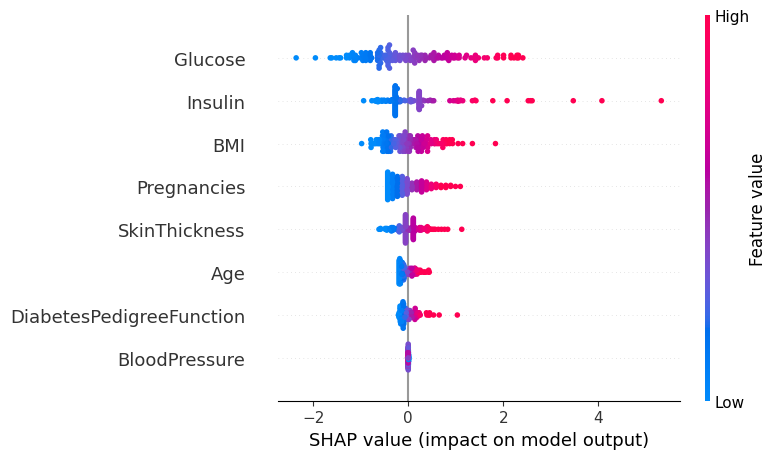

In [ ]:
# SHAP summary plot

shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns
)

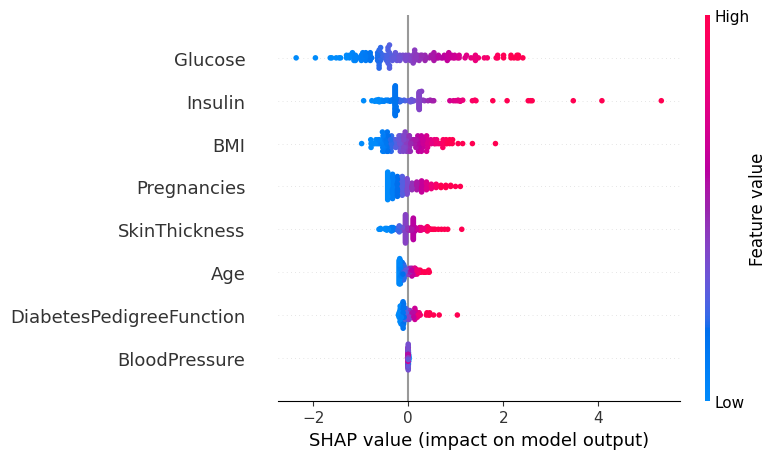

In [ ]:
# SHAP summary plot with original feature values

shap.summary_plot(
    shap_values.values,
    X_test,
    feature_names=X.columns
)